# Datenanalyse mit *Pandas* und *Matplotlib*

## Pandas
Pandas ist eine der am weiten verbreitesten Python-Biblitheken für Data Science. Pandas stellt 2 verschiedene Datentypen bereit:
* **Series**: entspricht einer Excel Spalte mit Index
<img src="series.png" alt="pands Series" width="100"/>
* **DataFrame**: 2D-Tabellenobjekt mit Spalten und Reihen (zusammengesetzt aus mehreren Series)
<img src="df.png" alt="pandas DataFrame" width="150"/>

Liegen Daten in dieser Form vor, können einfach Analysen, Datenmanipulation, Datenzusammenführung etc. damit durchgeführt werden.

Pandas liefert zudem eine `plot()` Funktion, die es ermöglicht, die im DataFrame gehaltenen Daten direkt zu plotten. `plot()`  basiert auf der Python-Bibliothek *matplotlib*.

## Seaborn

Seaborn ist eine pythonbasierte Plotting-Bibliothek, die ebenfalls auf matplotlib basiert. Seaborn kann gut mit pandas *DataFrame* Objekten umgehen.

## Jupyter notebook Grundlagen

Je nachdem, welches System verwendet wird, können die Shortcuts variieren. Hier sind einige der wichtigsten Shortcuts:
* Anzeigen aller Shortcuts `Ctrl + Shift + P`
* Ausführen einer Zelle und Sprung zur nächsten Zelle `Shift + Enter`
* Auswahl der nächsten Zelle `Esc -> Down`, Auswahl der vorigen Zelle `Esc -> Up`
* Printing
  1. Nutzung der Python-`print()` Funktion (für DataFrame-Objekte keine schöne Variante)
  2. Formatierte Ausgabe: Aufrufen einer Variablen in der letzten Zeile einer Zelle (ohne `print()`) oder Nutzung von `display()`

# Übungsaufgaben

## Dataset: Titanic

Verfügbar unter: https://www.kaggle.com/c/titanic/data. Arbeitsgrundlage für die Übungsaufgaben: **train.csv**.

### Erläuterung des Datensatzes
Der Datensatz enthält Passagierdaten des Kreuzfahrtschiffes Titanic, das am 15. April 1912 gesunken ist. Für jeden Passagier sind verschiedene Merkmale verfügbar:

| Merkmal | Erklärung|
| --------| ---------|
|survival | Hat der Passagier den Untergang überlebt? (0 = Nein, 1 = Ja) |
|pclass   | Ticket-/Passagierklasse (1= 1. Klasse, 2= 2. Klasse, 3 = 3. Klasse)|
|sex      | Geschlecht |
|age      | Alter in Jahren |
|sibsp    | Anzahl von Geschwistern/Ehepartnern  an Bord der Titanic |
|parch    | Anzahl von Eltern/Kindern an Bord der Titanic |
|fare     | Fahrpreis / Ticketpreis |
|cabin    | Kabinennummer |
|embarked | Einschiffungshafen (C = Cherbourg, Q = Queenstown, S = Southhampton)| 

In [1]:
# Load pandas
import pandas as pd

# Plotting library
import seaborn as sns
import matplotlib.pyplot as plt

# render plots in jupyter notebook
%matplotlib inline

## 2. CSV-Datei einlesen

Lade die Datei "titanic-train.csv" und weise sie der Veriablen `df` zu. Setze hierbei die *PassengerId* als DataFrame-Index.

**Tipp:** um zu kontrollieren, ob das Einlesen richtig funktioniert hat kannst du dir den Kopf des DataFrames anzeigen lassen.

In [2]:
df = pd.read_csv("titanic-train.csv", index_col="PassengerId")

print(df.head())

print(df.index)

             Survived  Pclass  \
PassengerId                     
1                   0       3   
2                   1       1   
3                   1       3   
4                   1       1   
5                   0       3   

                                                          Name     Sex   Age  \
PassengerId                                                                    
1                                      Braund, Mr. Owen Harris    male  22.0   
2            Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0   
3                                       Heikkinen, Miss. Laina  female  26.0   
4                 Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0   
5                                     Allen, Mr. William Henry    male  35.0   

             SibSp  Parch            Ticket     Fare Cabin Embarked  
PassengerId                                                          
1                1      0         A/5 21171   7.2500   NaN        S

## 3. Infos anzeigen

Erste Analyse des `df` DataFrames. Lasse dir Folgendes ausgeben:

#### 1. die Dimensionen des DataFrames

In [3]:
df.shape

(891, 11)

#### 2. die ersten 10 Zeilen des DataFrames anzeigen

In [4]:
df.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S


#### 3. alle Spaltennamen des DataFrames ausgeben

In [5]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

#### 4. eine statistische Zusammenfassung des DataFrames mit der Methode `discribe()` anzeigen

In [6]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


#### 5. Grundlegende Informationen zu dem Dataframe mit der Methode `info()` anzeigen

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 891 entries, 1 to 891
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 83.5+ KB


## 4. Indexing & Sorting

#### 1. Selektiere die Spalten *Cabin* und *Pclass* und gib den Head der Selektion aus

In [8]:
df_selection = df[['Cabin', 'Pclass']]

df_selection.head()

,Cabin,Pclass
PassengerId,,
1,NaN,3
2,C85,1
3,NaN,3
4,C123,1
5,NaN,3


#### 2. Selektiere die letzten 8 Reihen

In [9]:
df.tail(8)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.500,NaN,S
885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.050,NaN,S
886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.125,NaN,Q
887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.000,NaN,S
888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.000,B42,S
889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.450,NaN,S
890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.000,C148,C
891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.750,NaN,Q


#### 3. Selektiere die Namen und das Geschlecht für die Reihen 42 - 47

In [10]:
df.loc[42:47, ['Name', 'Sex']]

,Name,Sex
PassengerId,,
42,"Turpin, Mrs. William John Robert (Dorothy Ann ...",female
43,"Kraeff, Mr. Theodor",male
44,"Laroche, Miss. Simonne Marie Anne Andree",female
45,"Devaney, Miss. Margaret Delia",female
46,"Rogers, Mr. William John",male
47,"Lennon, Mr. Denis",male


#### 4. Selektiere die Reihen [550,560,570,580,590,600] und sortiere sie aufsteigend nach dem Ticketpreis

In [11]:
passenger_ids = [550, 560, 570, 580, 590, 600]

result_df = df.loc[passenger_ids].sort_values(by='Fare', ascending=True)

print(result_df)

             Survived  Pclass                                          Name  \
PassengerId                                                                   
570                 1       3                             Jonsson, Mr. Carl   
580                 1       3                           Jussila, Mr. Eiriik   
590                 0       3                           Murdlin, Mr. Joseph   
560                 1       3  de Messemaeker, Mrs. Guillaume Joseph (Emma)   
550                 1       2                Davies, Master. John Morgan Jr   
600                 1       1  Duff Gordon, Sir. Cosmo Edmund ("Mr Morgan")   

                Sex   Age  SibSp  Parch             Ticket     Fare Cabin  \
PassengerId                                                                 
570            male  32.0      0      0             350417   7.8542   NaN   
580            male  32.0      0      0  STON/O 2. 3101286   7.9250   NaN   
590            male   NaN      0      0         A./5. 3235 

#### 5. Selektiere nur jeden dritten Eintrag der Spalte *Age* und gib die ersten 10 Einträge aus

In [13]:
auswahl = df.loc[::3]

auswahl.head(10)

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C
13,0,3,"Saundercock, Mr. William Henry",male,20.0,0,0,A/5. 2151,8.0500,NaN,S
16,1,2,"Hewlett, Mrs. (Mary D Kingcome)",female,55.0,0,0,248706,16.0000,NaN,S
19,0,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
22,1,2,"Beesley, Mr. Lawrence",male,34.0,0,0,248698,13.0000,D56,S
25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S


### 4.1 Bedingte Selektion

#### 1. Wie viele Passagiere sind 30 Jahre alt?

In [14]:
df.loc[df['Age'] == 30].shape[0]

25

#### 2. Welche weiblichen Passagiere haben Eltern oder Kinder (Parch) an Board und sind jünger als 40 Jahre?

In [16]:
df.loc[(df['Sex'] == 'female') & (df['Parch'] > 0) & (df['Age'] < 40)]

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
25,0,3,"Palsson, Miss. Torborg Danira",female,8.0,3,1,349909,21.0750,NaN,S
26,1,3,"Asplund, Mrs. Carl Oscar (Selma Augusta Emilia...",female,38.0,1,5,347077,31.3875,NaN,S
44,1,2,"Laroche, Miss. Simonne Marie Anne Andree",female,3.0,1,2,SC/Paris 2123,41.5792,NaN,C
...,...,...,...,...,...,...,...,...,...,...,...
854,1,1,"Lines, Miss. Mary Conover",female,16.0,0,1,PC 17592,39.4000,D28,S
856,1,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
859,1,3,"Baclini, Mrs. Solomon (Latifa Qurban)",female,24.0,0,3,2666,19.2583,NaN,C


#### 3. Wie viele Passagiere haben mindestens einen Verwandten an Board (SibSp und Parch)?

In [17]:
df.loc[(df['SibSp'] + df['Parch']) > 0].shape[0]

354

## 5. Verschiedenes

#### 1. Lasse dir eine Auflistung der Anzahlen von eindeutigen Werten der Spalte *Embarked* ausgeben

In [15]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

#### 2. Binary Encoding
1. Ersetze die String-Werte der Spalte 'Sex' durch Integer Werte (0 = female,1 =male).
2. Benenne die Spalte in `Male` um.

In [18]:
df['Sex'] = df['Sex'].replace({'female': 0, 'male': 1})

/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_10046/409730233.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Sex'] = df['Sex'].replace({'female': 0, 'male': 1})


In [19]:
df.rename(columns={'Sex': 'Male'}, inplace=True)

In [20]:
df[['Male', 'Name']].head()

,Male,Name
PassengerId,,
1,1,"Braund, Mr. Owen Harris"
2,0,"Cumings, Mrs. John Bradley (Florence Briggs Th..."
3,0,"Heikkinen, Miss. Laina"
4,0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)"
5,1,"Allen, Mr. William Henry"


In [21]:
df.head()

,Survived,Pclass,Name,Male,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,NaN,S


## 6. Missing values

1. Enthält der DataFrame missing values?

In [23]:
df.isna()

,Survived,Pclass,Name,Male,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
887,False,False,False,False,False,False,False,False,False,True,False
888,False,False,False,False,False,False,False,False,False,False,False
889,False,False,False,False,True,False,False,False,False,True,False


#### 2. Wie viele NaN Werte enthält der DataFrame in jeder einzelnen Spalte?

In [26]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Male          0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

#### 3. Entferne diejenigen Reihen, die NaN Werte in der Spalte *Embarked* enthalten

In [27]:
df.dropna(subset=['Embarked'], inplace=True)

In [28]:
df.isna().sum()

Survived      0
Pclass        0
Name          0
Male          0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

#### 4. Ersetze die NaN Werte der Spalte *Alter* mit dem durchschnittlichen Alter

In [29]:
durchschnitts_alter = df['Age'].mean()

print(f"Das verwendete Durchschnittsalter beträgt: {durchschnitts_alter:.2f}")

Das verwendete Durchschnittsalter beträgt: 29.64


In [30]:
df['Age'].fillna(durchschnitts_alter, inplace=True)

df.isna().sum()

/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_10046/814371377.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(durchschnitts_alter, inplace=True)


Survived      0
Pclass        0
Name          0
Male          0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

## 7. Erzeuge weitere Spalten 

#### 1. Hat die Spalte "Cabin" noch fehlende Werte?

In [31]:
df['Cabin'].isna().sum()

np.int64(687)

#### 2. Fülle fehlende Werte mit U0 auf

In [32]:
df['Cabin'].fillna('U0', inplace=True)
df['Cabin'].isna().sum()

/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_10046/1996938846.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Cabin'].fillna('U0', inplace=True)


np.int64(0)

#### 3. Lasse dir eine Auflistung der Anzahlen von eindeutigen Werten der Spalte *Cabin* ausgeben

In [33]:
df['Cabin'].value_counts()

Cabin
U0             687
C23 C25 C27      4
G6               4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 147, dtype: int64

#### 4. Die Titanic hatte 8 Decks (1 bis 8). Ordne jedem Passagier seinem Deck zu. Dieses kann aus dem ersten Buchstaben von 'Cabin' abgelesen werden, beispielsweise 'E34' entspricht dem Deck 5. Nutze diese Zuordnung: '{"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "U": 8, Sonderfälle: 0}'

In [34]:
deck_mapping = {"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6, "G": 7, "U": 8}

df['Deck_Char'] = df['Cabin'].str[0]

In [35]:
df['Deck'] = df['Deck_Char'].map(deck_mapping).fillna(0).astype(int)

df[['Cabin', 'Deck']].head(10)

,Cabin,Deck
PassengerId,,
1,U0,8
2,C85,3
3,U0,8
4,C123,3
5,U0,8
6,U0,8
7,E46,5
8,U0,8
9,U0,8


#### 5. Lösche die Spalte 'Cabin'

In [36]:
df.drop('Cabin', axis=1, inplace=True)

df.columns.tolist()

['Survived',
 'Pclass',
 'Name',
 'Male',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Embarked',
 'Deck_Char',
 'Deck']

#### 6. Ordne jedem Passagier eine Altersklasse zu. Nenne die neue Spalte "Altersklasse". Die Klassen sollen wie folgt definiert sein:
- Alter < 12 Jahre --> "Kinder"
- 12 <= Alter < 18 Jahre --> "Jugendliche"
- 18 Jahre <= Alter < 60 Jahre --> "Erwachsene"
- Alter > 60 Jahre --> "Senioren"

Wie viele Passagiere sind in jeder Altersklasse?

In [37]:
bins = [0, 12, 18, 60, 10000] 

labels = ["Kinder", "Jugendliche", "Erwachsene", "Senioren"]

In [38]:
df['Altersklasse'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels,
    right=False, # Linke Grenze ist inklusive
    include_lowest=True # Niedrigster Wert ist inklusive
)

df[['Age', 'Altersklasse']].head()

,Age,Altersklasse
PassengerId,,
1,22.0,Erwachsene
2,38.0,Erwachsene
3,26.0,Erwachsene
4,35.0,Erwachsene
5,35.0,Erwachsene


In [40]:
df.head(20)

,Survived,Pclass,Name,Male,Age,SibSp,Parch,Ticket,Fare,Embarked,Deck_Char,Deck,Altersklasse
PassengerId,,,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",1,22.000000,1,0,A/5 21171,7.2500,S,U,8,Erwachsene
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.000000,1,0,PC 17599,71.2833,C,C,3,Erwachsene
3,1,3,"Heikkinen, Miss. Laina",0,26.000000,0,0,STON/O2. 3101282,7.9250,S,U,8,Erwachsene
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.000000,1,0,113803,53.1000,S,C,3,Erwachsene
5,0,3,"Allen, Mr. William Henry",1,35.000000,0,0,373450,8.0500,S,U,8,Erwachsene
6,0,3,"Moran, Mr. James",1,29.642093,0,0,330877,8.4583,Q,U,8,Erwachsene
7,0,1,"McCarthy, Mr. Timothy J",1,54.000000,0,0,17463,51.8625,S,E,5,Erwachsene
8,0,3,"Palsson, Master. Gosta Leonard",1,2.000000,3,1,349909,21.0750,S,U,8,Kinder
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",0,27.000000,0,2,347742,11.1333,S,U,8,Erwachsene


## Plots (Data Anlaysis)
### Seaborn

#### 1. Erstelle einen pairplot für die Spalten: [Pclass, Fare, Male, Parch, SibSp, Age], Färbe die überlebenden und verstorbenen Passagiere unterschiedlich ein (Argument: "hue")

Fragestellungen:
* Was stellt der Pairplot dar?
* Welche Zusammenhänge zwischen dem Überleben des Untergangs der Titanic und den einzelnen Features lassen sich ablesen?
* Welche Zusammenhänge zwischen den Features lassen sich ablesen?

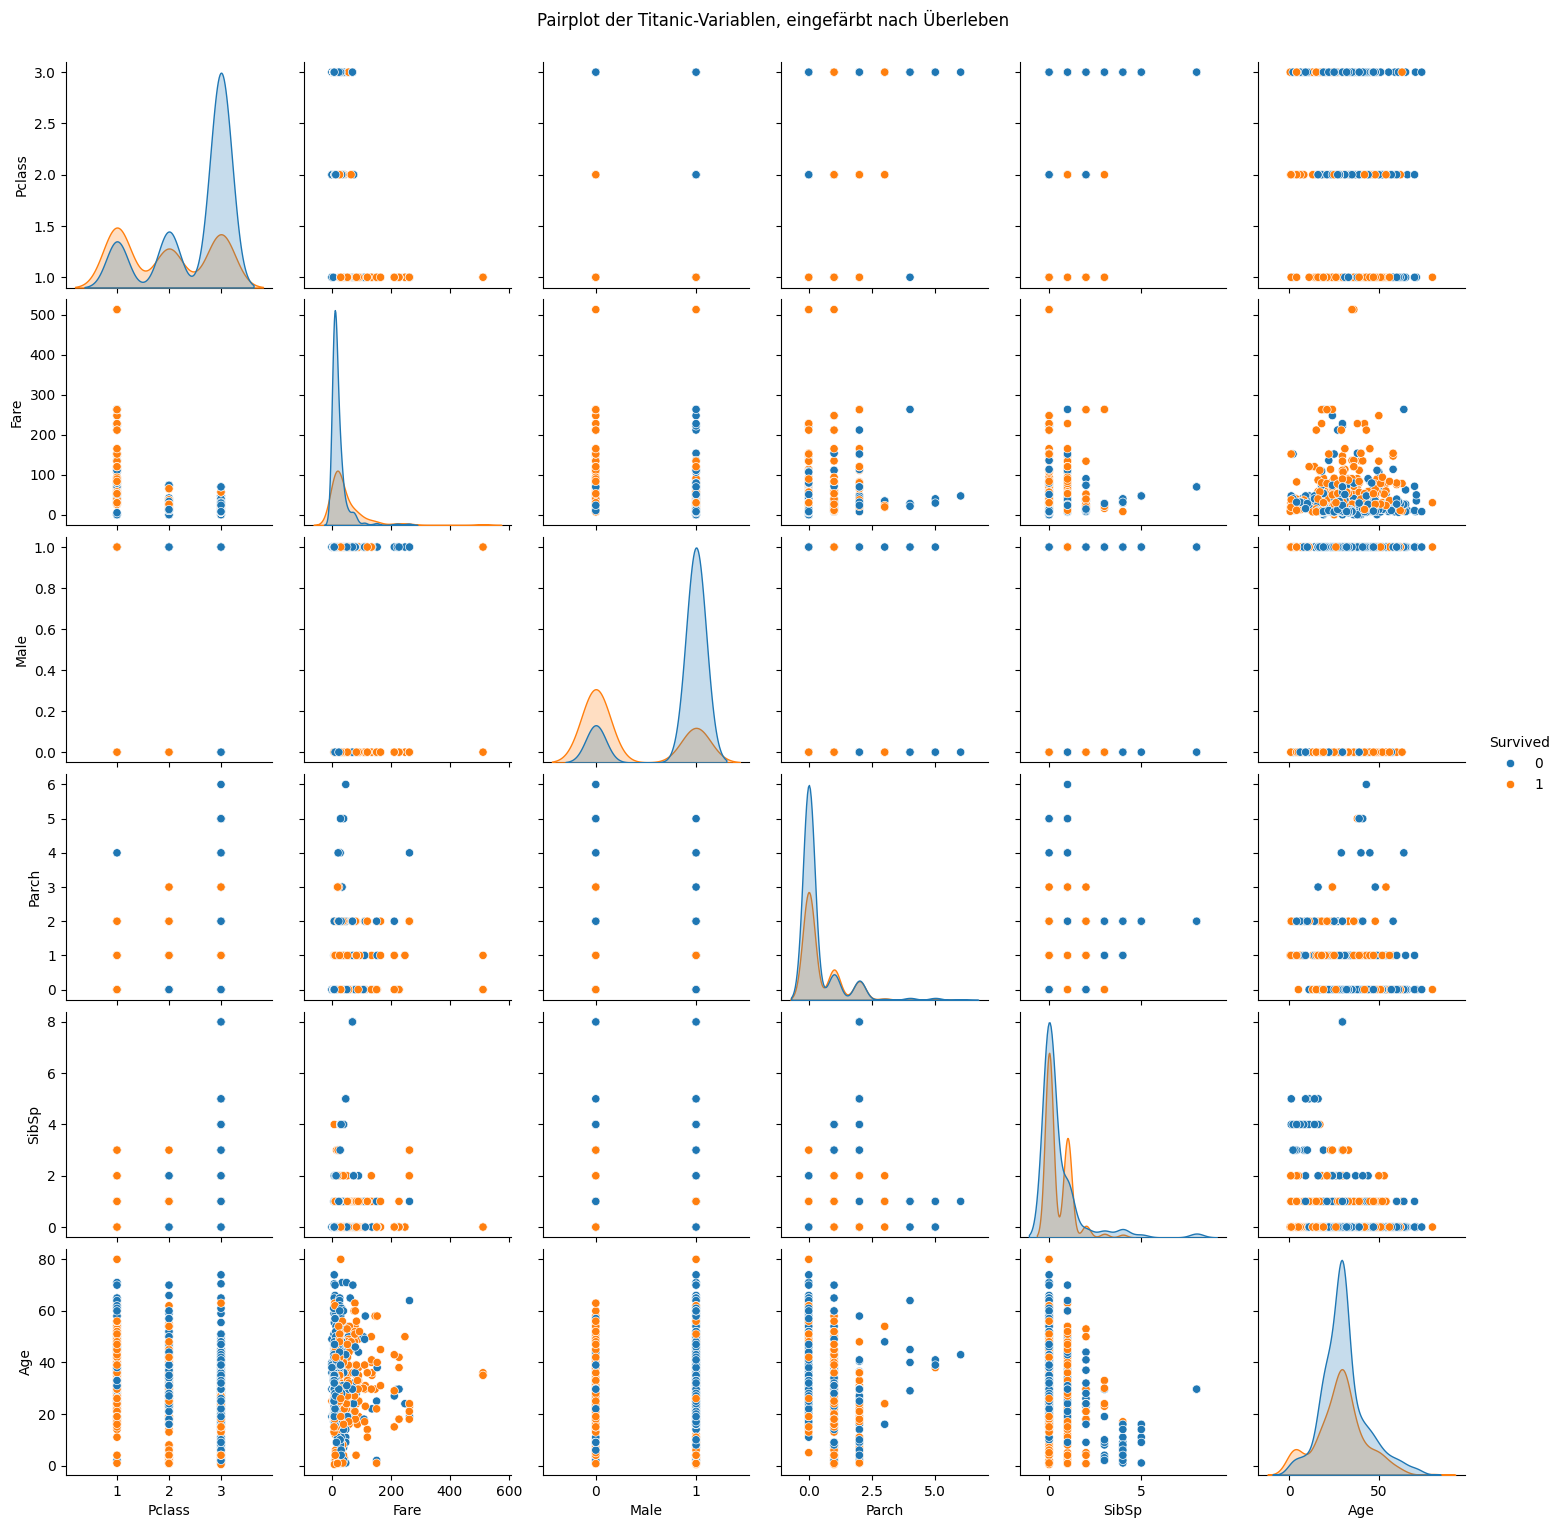

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

cols_to_plot = ['Pclass', 'Fare', 'Male', 'Parch', 'SibSp', 'Age']

g = sns.pairplot(df, vars=cols_to_plot, hue='Survived')

g.fig.suptitle('Pairplot der Titanic-Variablen, eingefärbt nach Überleben', y=1.02)

plt.show()

In [45]:
print("\n--- Analyse des Pairplots ---")

print("1. Der Pairplot zeigt die paarweisen Beziehungen (Streudiagramme) aller ausgewählten Variablen sowie die univariate Verteilung (Histogramm) jeder Variable.")

print("2. Zusammenhänge mit Überleben (Survived):")
print("   - Hohe Überlebensrate bei: 1. Klasse (Pclass=1), höheren Ticketpreisen (Fare), weiblichem Geschlecht (Male=0) und jüngeren Passagieren (Age).")
print("   - Niedrige Überlebensrate bei: 3. Klasse (Pclass=3) und männlichem Geschlecht (Male=1).")

print("3. Zusammenhänge zwischen Features:")
print("   - Starker (negativer) Zusammenhang zwischen Pclass und Fare (höhere Klasse = höherer Preis).")
print("   - Leichte positive Korrelation zwischen SibSp (Geschwister/Ehepartner) und Parch (Eltern/Kinder) (Familien reisen zusammen).")


--- Analyse des Pairplots ---
1. Der Pairplot zeigt die paarweisen Beziehungen (Streudiagramme) aller ausgewählten Variablen sowie die univariate Verteilung (Histogramm) jeder Variable.
2. Zusammenhänge mit Überleben (Survived):
   - Hohe Überlebensrate bei: 1. Klasse (Pclass=1), höheren Ticketpreisen (Fare), weiblichem Geschlecht (Male=0) und jüngeren Passagieren (Age).
   - Niedrige Überlebensrate bei: 3. Klasse (Pclass=3) und männlichem Geschlecht (Male=1).
3. Zusammenhänge zwischen Features:
   - Starker (negativer) Zusammenhang zwischen Pclass und Fare (höhere Klasse = höherer Preis).
   - Leichte positive Korrelation zwischen SibSp (Geschwister/Ehepartner) und Parch (Eltern/Kinder) (Familien reisen zusammen).


#### 2. Erstelle ein Säulendiagramm über die Klassenverteilung der Spalte Survived (Gegenüberstellung der Anzahl an Einträgen in den beiden Klassen)

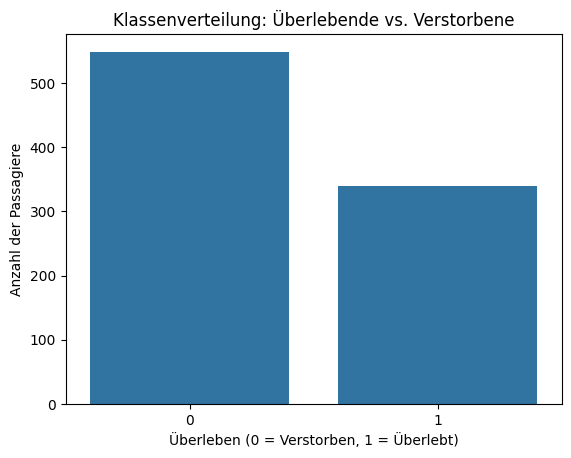

In [46]:
sns.countplot(x='Survived', data=df)

plt.title('Klassenverteilung: Überlebende vs. Verstorbene')
plt.xlabel('Überleben (0 = Verstorben, 1 = Überlebt)')
plt.ylabel('Anzahl der Passagiere')

plt.show()

#### ZUSATZAUFGABE
#### 3. Erstelle einen Violinenplot mit folgenden Eigenschaften:
* X-Achse: "Pclass", Y-Achse: "Age", Farbtonvariable (engl. "hue"): "Survived", split=True

Was lässt sich daraus ableiten?

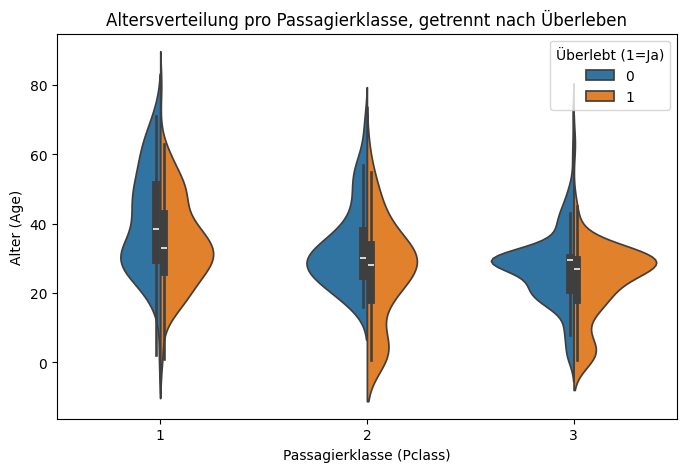

In [47]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Pclass', y='Age', hue='Survived', data=df, split=True)

# Füge Titel und Achsenbeschriftungen hinzu
plt.title('Altersverteilung pro Passagierklasse, getrennt nach Überleben')
plt.xlabel('Passagierklasse (Pclass)')
plt.ylabel('Alter (Age)')
plt.legend(title='Überlebt (1=Ja)')

plt.show()

In [48]:
print("Klasse und Alter waren entscheidend für das Überleben. Unabhängig von der Klasse hatten Kinder eine relativ hohe Überlebenschance. In der 3. Klasse war die Überlebenswahrscheinlichkeit für Erwachsene am geringsten.")

Klasse und Alter waren entscheidend für das Überleben. Unabhängig von der Klasse hatten Kinder eine relativ hohe Überlebenschance. In der 3. Klasse war die Überlebenswahrscheinlichkeit für Erwachsene am geringsten.


# Quiz

### 1. Welche Passagiere haben am meisten für ihr Ticket gezahlt? Wie alt waren sie, auf welchem Deck waren sie untergebracht und wie viel haben sie für die Tickets gezahlt?

In [49]:
max_fare = df['Fare'].max()

passagiere_teuerstes_ticket = df.loc[df['Fare'] == max_fare]

antwort = passagiere_teuerstes_ticket[['Name', 'Age', 'Deck', 'Fare']]

print(f"Der höchste bezahlte Ticketpreis beträgt: ${max_fare:.2f}\n")
print("Passagiere mit dem teuersten Ticket:")
print(antwort)

Der höchste bezahlte Ticketpreis beträgt: $512.33

Passagiere mit dem teuersten Ticket:
                                           Name   Age  Deck      Fare
PassengerId                                                          
259                            Ward, Miss. Anna  35.0     8  512.3292
680          Cardeza, Mr. Thomas Drake Martinez  36.0     2  512.3292
738                      Lesurer, Mr. Gustave J  35.0     2  512.3292


### 2. Was sind die 10 häufigsten Nachnamen an Board?

In [50]:
df['Surname'] = df['Name'].str.split(',').str[0].str.strip()

top_10_surnames = df['Surname'].value_counts().head(10)

print("Die 10 häufigsten Nachnamen an Bord:")
print(top_10_surnames)

Die 10 häufigsten Nachnamen an Bord:
Surname
Andersson    9
Sage         7
Goodwin      6
Skoog        6
Panula       6
Johnson      6
Carter       6
Rice         5
Asplund      4
Harper       4
Name: count, dtype: int64


### 3. Wie hieß der jüngste Passagier der Titanic und wie alt war er?

In [51]:
min_age = df['Age'].min()

juengster_passagier = df.loc[df['Age'] == min_age, ['Name', 'Age']]

print(f"Das jüngste Alter im Datensatz beträgt: {min_age} Jahre")
print("\n Jüngsten Passagier:")
print(juengster_passagier)

Das jüngste Alter im Datensatz beträgt: 0.42 Jahre

 Jüngsten Passagier:
                                        Name   Age
PassengerId                                       
804          Thomas, Master. Assad Alexander  0.42


### 4. Überleben männlicher Passagiere:
#### Haben mehr männliche Passagiere der Passagierklasse 1 oder der Passagierklasse 3 den Untergang überlebt? (absolut und relativ)

In [52]:
survived_male_pclass1_abs = df.loc[(df['Male'] == 1) & (df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0]

survived_male_pclass3_abs = df.loc[(df['Male'] == 1) & (df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0]

print(f"Absolute Überlebende in Pclass 1 (männlich): {survived_male_pclass1_abs}")
print(f"Absolute Überlebende in Pclass 3 (männlich): {survived_male_pclass3_abs}")

Absolute Überlebende in Pclass 1 (männlich): 45
Absolute Überlebende in Pclass 3 (männlich): 47


In [53]:
total_male_pclass1 = df.loc[(df['Male'] == 1) & (df['Pclass'] == 1)].shape[0]

total_male_pclass3 = df.loc[(df['Male'] == 1) & (df['Pclass'] == 3)].shape[0]

survived_male_pclass1_rel = (survived_male_pclass1_abs / total_male_pclass1) * 100
survived_male_pclass3_rel = (survived_male_pclass3_abs / total_male_pclass3) * 100

print("\nRelative Überlebensraten:")
print(f"Rel. Überlebensrate Pclass 1 (männlich): {survived_male_pclass1_rel:.2f}% (Basis: {total_male_pclass1} Männer)")
print(f"Rel. Überlebensrate Pclass 3 (männlich): {survived_male_pclass3_rel:.2f}% (Basis: {total_male_pclass3} Männer)")


Relative Überlebensraten:
Rel. Überlebensrate Pclass 1 (männlich): 36.89% (Basis: 122 Männer)
Rel. Überlebensrate Pclass 3 (männlich): 13.54% (Basis: 347 Männer)


#### Plotte die Anzahl der männlichen Überlebenden für die Altersklassen. Unterscheide wieder in "überlebt" und "nicht überlebt"

Tipp: Nutze hierfür ein Seaborn Countplot

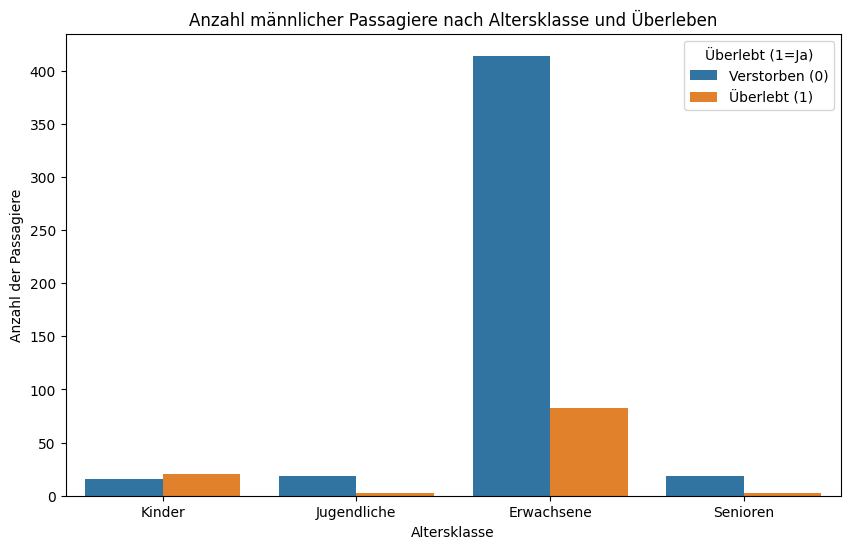

In [54]:
df_male = df[df['Male'] == 1]

plt.figure(figsize=(10, 6))
sns.countplot(x='Altersklasse', hue='Survived', data=df_male, order=["Kinder", "Jugendliche", "Erwachsene", "Senioren"])

plt.title('Anzahl männlicher Passagiere nach Altersklasse und Überleben')
plt.xlabel('Altersklasse')
plt.ylabel('Anzahl der Passagiere')
plt.legend(title='Überlebt (1=Ja)', labels=['Verstorben (0)', 'Überlebt (1)'])

plt.show()

### 6. Subplots
Erstelle einen Plot mit 2 Subplots (1 Reihe, 2 Spalten).

Die beiden Plots sollen die Anzahl der 
* a) Passagiere der drei Ausgangshäfen (*Embarked*),
* b) der männlichen Passagiere,

getrennt nach Überleben/nicht-Überleben darstellen.

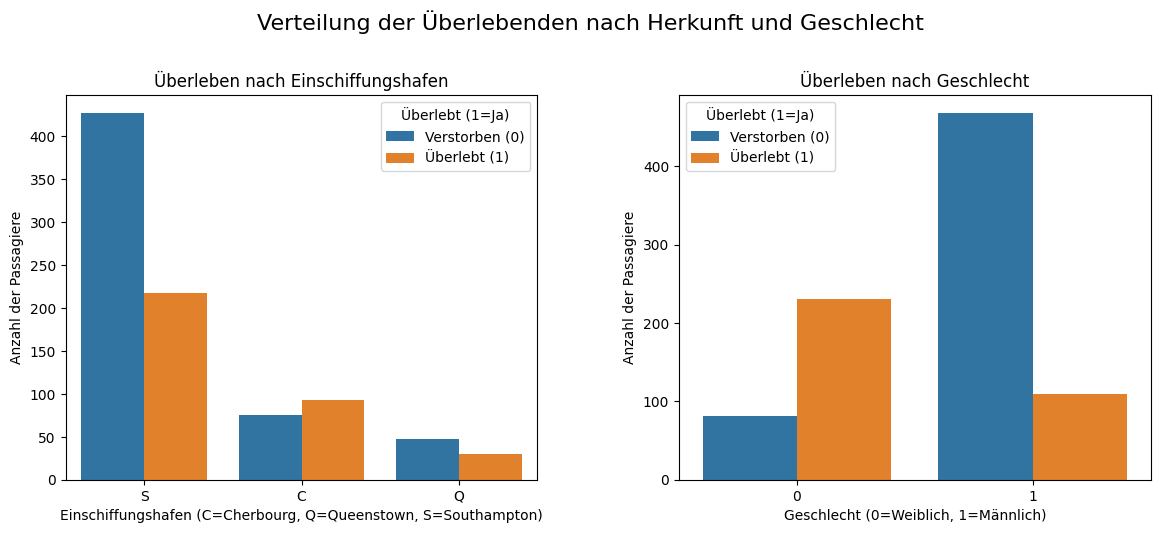

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plt.subplots_adjust(wspace=0.3)

# --- Subplot 1: Überleben nach Einschiffungshafen (Embarked) ---
sns.countplot(x='Embarked', hue='Survived', data=df, ax=axes[0])
axes[0].set_title('Überleben nach Einschiffungshafen')
axes[0].set_xlabel('Einschiffungshafen (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[0].set_ylabel('Anzahl der Passagiere')
axes[0].legend(title='Überlebt (1=Ja)', labels=['Verstorben (0)', 'Überlebt (1)'])

# --- Subplot 2: Überleben nach Geschlecht (Männlich/Weiblich) ---
sns.countplot(x='Male', hue='Survived', data=df, ax=axes[1])
axes[1].set_title('Überleben nach Geschlecht')
axes[1].set_xlabel('Geschlecht (0=Weiblich, 1=Männlich)')
axes[1].set_ylabel('Anzahl der Passagiere')
axes[1].legend(title='Überlebt (1=Ja)', labels=['Verstorben (0)', 'Überlebt (1)'])

plt.suptitle('Verteilung der Überlebenden nach Herkunft und Geschlecht', fontsize=16, y=1.05)
plt.show()

### 7. Wie war die Überlebenswahrscheinlichkeit für jede Altersklasse?

In [56]:
survival_probability = df.groupby('Altersklasse')['Survived'].mean().sort_values(ascending=False)

print("--- Überlebenswahrscheinlichkeit pro Altersklasse ---")
# Formatiere die Ausgabe als Prozent
print(survival_probability.map('{:.2%}'.format))

--- Überlebenswahrscheinlichkeit pro Altersklasse ---
Altersklasse
Kinder         57.35%
Jugendliche    48.89%
Erwachsene     36.35%
Senioren       24.00%
Name: Survived, dtype: object


/var/folders/h1/7s_jyhrs0gd118jm5hmk18lw0000gn/T/ipykernel_10046/1072870348.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  survival_probability = df.groupby('Altersklasse')['Survived'].mean().sort_values(ascending=False)


# Principle Component Analysis

Entferne zunächst die Features `Name`, `Altersklasse` und `Ticket` aus dem Dataframe. Das Feature `Embarked` enthält noch Strings, die wir für unsere weitere Analyse nicht verarbeiten können. Wende hier die One-Hot-Encoding Methode an. Tipp: Pandas besitzt dafür die `get_dummies()`-Methode.

In [57]:
columns_to_drop = ['Name', 'Altersklasse', 'Ticket']
df.drop(columns=columns_to_drop, axis=1, inplace=True)

In [58]:
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("--- DataFrame nach Bereinigung und Kodierung ---")
print("Die ersten 5 Zeilen:")
print(df.head())
print("\nNeue Spaltenliste:")
print(df.columns.tolist())

--- DataFrame nach Bereinigung und Kodierung ---
Die ersten 5 Zeilen:
             Survived  Pclass  Male   Age  SibSp  Parch     Fare Deck_Char  \
PassengerId                                                                  
1                   0       3     1  22.0      1      0   7.2500         U   
2                   1       1     0  38.0      1      0  71.2833         C   
3                   1       3     0  26.0      0      0   7.9250         U   
4                   1       1     0  35.0      1      0  53.1000         C   
5                   0       3     1  35.0      0      0   8.0500         U   

             Deck    Surname  Embarked_Q  Embarked_S  
PassengerId                                           
1               8     Braund       False        True  
2               3    Cumings       False       False  
3               8  Heikkinen       False        True  
4               3   Futrelle       False        True  
5               8      Allen       False        True 

Lass dir nun die Korrelationsmatrix des Datensatzes ausgeben und plotten. Welche Zusammenhänge sind erkennbar?

            Survived    Pclass      Male       Age     SibSp     Parch  \
Survived    1.000000 -0.335549 -0.541585 -0.074513 -0.034040  0.083151   
Pclass     -0.335549  1.000000  0.127741 -0.328256  0.081656  0.016824   
Male       -0.541585  0.127741  1.000000  0.089339 -0.116348 -0.247508   
Age        -0.074513 -0.328256  0.089339  1.000000 -0.231908 -0.178013   
SibSp      -0.034040  0.081656 -0.116348 -0.231908  1.000000  0.414542   
Parch       0.083151  0.016824 -0.247508 -0.178013  0.414542  1.000000   
Fare        0.255290 -0.548193 -0.179958  0.088780  0.160887  0.217532   
Deck       -0.285119  0.743865  0.108010 -0.247759  0.040864 -0.031813   
Embarked_Q  0.004536  0.220558 -0.075217 -0.013416 -0.026692 -0.081585   
Embarked_S -0.151777  0.076466  0.121405 -0.021166  0.069438  0.061512   

                Fare      Deck  Embarked_Q  Embarked_S  
Survived    0.255290 -0.285119    0.004536   -0.151777  
Pclass     -0.548193  0.743865    0.220558    0.076466  
Male       -0.

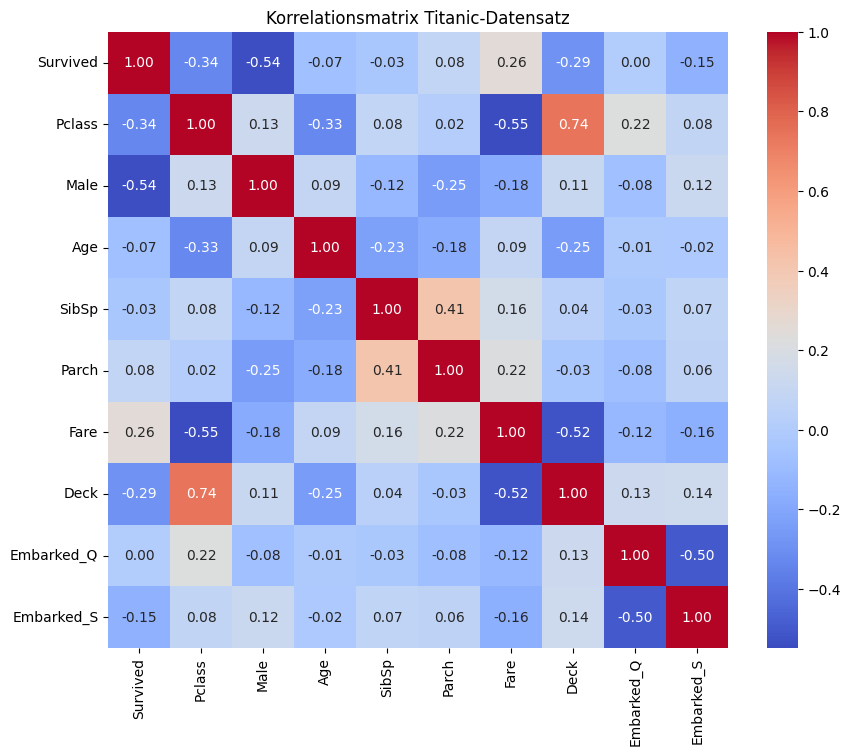

In [63]:
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix)

plt.figure(figsize=(10,8))

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix Titanic-Datensatz')
plt.show()

Wir wollen jetzt die PCA-Methode (Principal Component Analysis) verwenden, um die Dimension des Datensatzes zu reduzieren. In der nächsten Zelle werden daher die notwendigen Pakete importiert und das Dataframe vorverarbeitet. Führe die Zelle aus. Die Datenpunkte sind danach in der Variable `arr` gespeichert.

In [67]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 1.8 MB/s  0:00:06 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.4/39.4 MB 1.7 MB/s  0:00:22m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


In [72]:
df.drop('Deck', axis=1, inplace=True)

In [75]:
non_numeric_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if non_numeric_cols:
    print(f"Entferne verbleibende nicht-numerische Spalten: {non_numeric_cols}")
    df.drop(columns=non_numeric_cols, axis=1, inplace=True)
else:
    print("DataFrame ist nun vollständig numerisch.")

Entferne verbleibende nicht-numerische Spalten: ['Deck_Char', 'Surname']


In [76]:
from sklearn.decomposition import PCA
from sklearn import preprocessing

X = df.to_numpy()

arr = preprocessing.normalize(preprocessing.scale(X))

Initialisiere jetzt eine Instanz der `PCA`-Klasse mit **2** Komponenten und fitte diese mit ihrer eingebauten Methode auf den Datensatz. Transformiere den gleichen Datensatz danach. Überprüfe die Dimension des neuen Datensatzes mit `.shape`.

In [77]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(arr)
X_pca.shape

(889, 2)

Weise nun deinen transformierten Datensatz der Variable `data` zu und führe die Zelle aus. Was wird hier geplottet? Wieso sind die Ausprägungen der einzelnen Features in Clustern zu sehen?

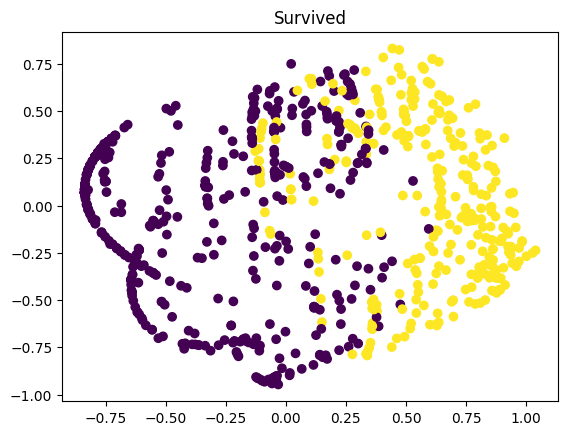

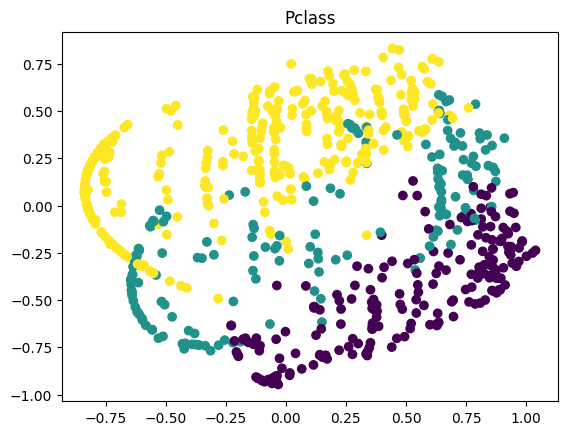

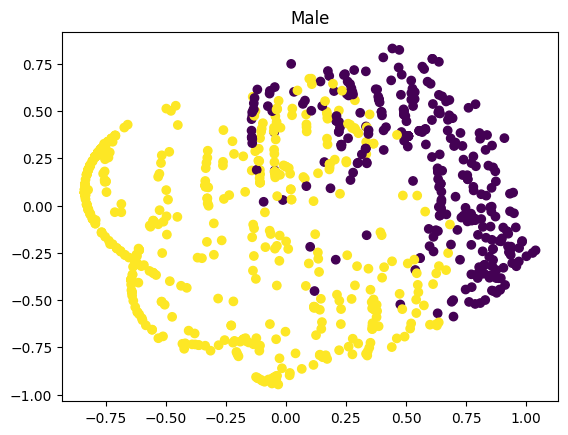

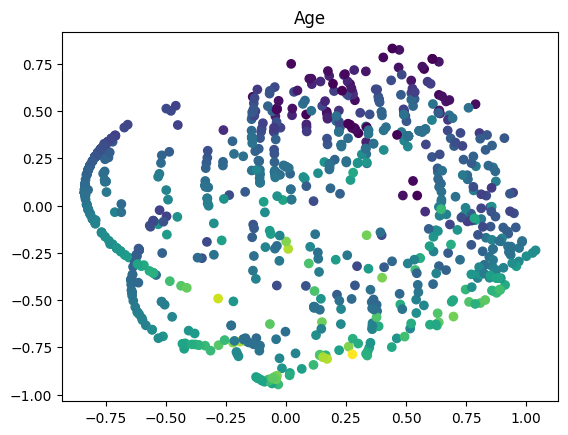

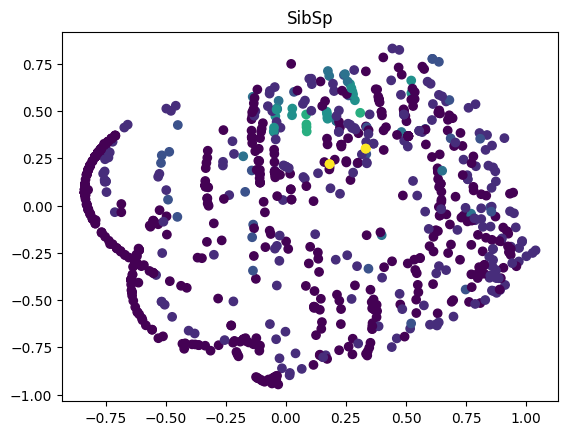

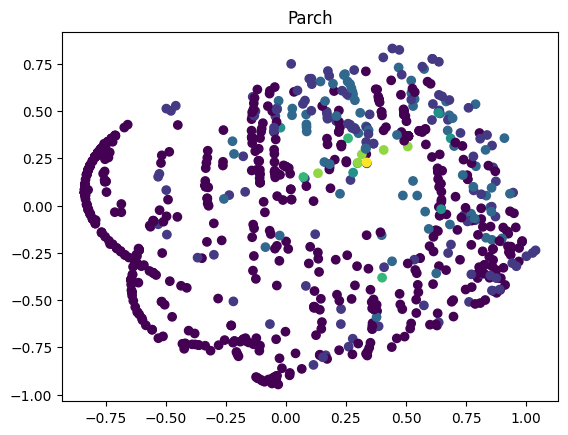

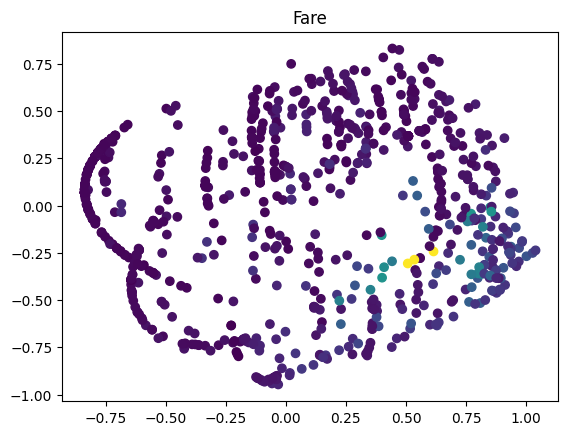

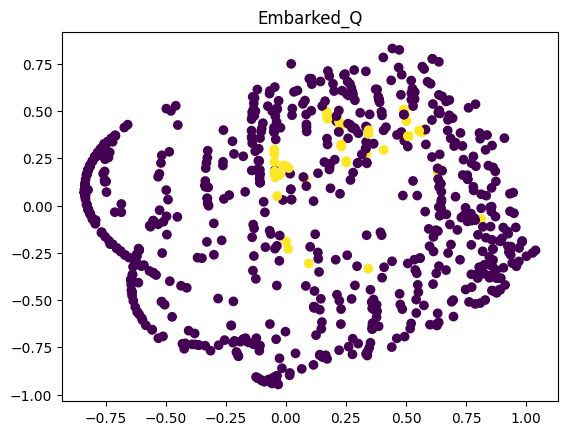

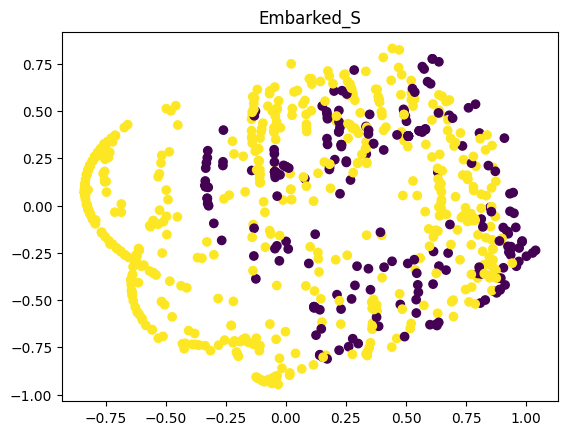

In [78]:
data = X_pca

feat_list = list(df.columns)

for feat in feat_list:
    plt.title(feat)
    plt.scatter(data[:,0], data[:,1], edgecolors='face', c=df[feat].values)
    plt.show()